# Part 4: Data-driven model of battery with DMDc

In this notebook, we demonstrate how we can create data-driven models with Dynamic Mode Decomposition (DMD) for a battery and use them in Collimator.

## Dataset
We utilise the same dataset as in the previous tutorial. We also resample the dataset at a frequency of 10Hz.

## Data driven modelling by Dynamic Mode Decomposition with control (DMDc)

Here, our interest is to find a discrete-time battery model which takes $i[k]$ at a time-index $k$ and generates outputs $v_t[k]$ and the ampere-hours discharged $d[k]$. We know that the SoC ($s$) is related to the measurement of Ampere-hours discharged $d$ through the algebraic relation: $s = \frac{Q-d}{Q}$. Thus, for learning the model we work with direct measurement $d$ instead of $s$.

Considering $v_t[k]$ and $d[k]$ as the state variables and $i[k]$ as the control input, we seek an approximate model for the battery dynamics with DMDc of the following form

\begin{align}
\begin{pmatrix}
v_t[k+1] \\ d[k+1]
\end{pmatrix} = 
A 
\begin{pmatrix}
v_t[k] \\ d[k]
\end{pmatrix} +
B
\left( i[k] \right),
\end{align}

where $A$ is a $2\times 2$ matrix and $B$ is $1\times 1$ matrix. 


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np

from math import ceil

from jax import config

config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp

from scipy.io import loadmat

train_file_name = "dataset_25deg/10-28-18_17.44 551_UDDS_25degC_LGHG2.mat"
val_file_name = "dataset_25deg/10-29-18_14.41 551_Mixed1_25degC_LGHG2.mat"

tain_data = loadmat(train_file_name)
val_data = loadmat(val_file_name)

Q = 3.0  # battery capacity is known to be 3Ah (LG HG2 cell)


def extract_features_from_matfile(filename, Q=3.0, dt=0.1):
    data = loadmat(filename)
    t = data["meas"][0][0][0]
    vt = data["meas"][0][0][2]
    curr = -data["meas"][0][0][3]
    D = -data["meas"][0][0][4]

    # Resample
    T_end = t[-1, 0]
    t_resampled = np.linspace(0.0, T_end, ceil(T_end / dt))
    vt_resampled = np.interp(t_resampled, t[:, 0], vt[:, 0])
    curr_resampled = np.interp(t_resampled, t[:, 0], curr[:, 0])
    D_resampled = np.interp(t_resampled, t[:, 0], D[:, 0])

    return (t_resampled, vt_resampled, curr_resampled, D_resampled)


t_train, vt_train, curr_train, d_train = extract_features_from_matfile(train_file_name)
t_val, vt_val, curr_val, d_val = extract_features_from_matfile(val_file_name)

We utilise the `pykoopman` package to generate the Dynamic Mode Model with control:

In [2]:
import pykoopman as pk

state_names = ["$v_t$", "$d$"]
state_data = np.vstack([vt_train, d_train]).T
control_data = curr_train.reshape((curr_train.size, 1))

dmdc = pk.regression.DMDc(svd_rank=None)
model = pk.Koopman(regressor=dmdc)
model.fit(state_data, u=control_data)

Aest = model.ur @ model.A @ model.ur.T
Best = model.ur @ model.B

print("Estimated A and B matrices:")
print(f"{Aest=}")
print(f"{Best=}")

Estimated A and B matrices:
Aest=array([[1.00000680e+00, 7.95046840e-06],
       [2.45928084e-08, 9.99999984e-01]])
Best=array([[-7.42636033e-05],
       [ 2.76371923e-05]])


We can now simulate the model, initialising the model at the initial values of the state measurements, and see how its predictions compare with the experiment data.

RMS: error: [0.6352260126311515, 0.0010199625632842713]


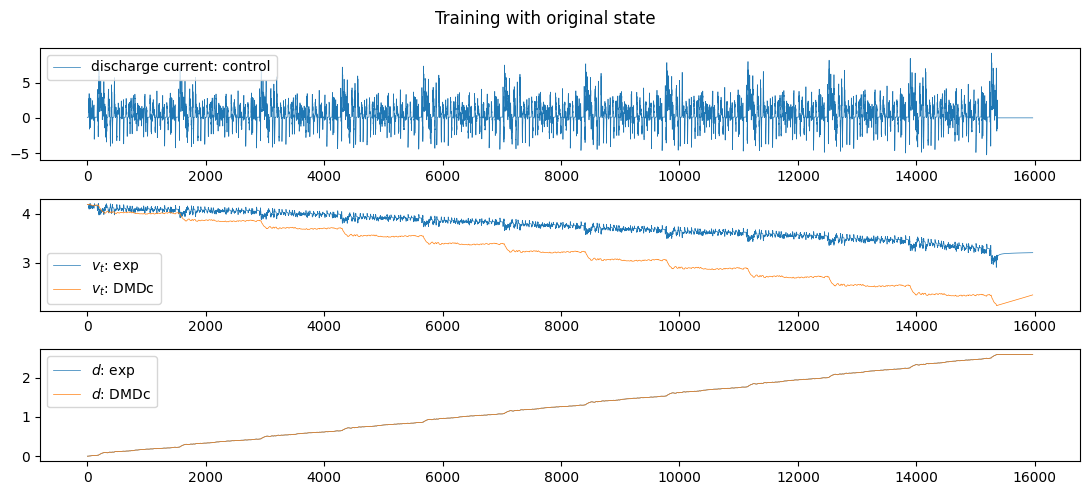

In [3]:
initial_state = state_data[0, :]
n_steps = state_data.shape[0] - 1
lw = 0.5
pred_state = model.simulate(initial_state, u=control_data[:-1], n_steps=n_steps)
pred_state = np.vstack([initial_state, pred_state])


def compute_prediction_error(pred_state, state_data):
    rms_err = []
    for y, x in zip(pred_state.T, state_data.T):
        rms_err.append(np.sqrt(np.average((y - x) ** 2)))
    return rms_err


print("RMS: error:", compute_prediction_error(pred_state, state_data))

fig, axs = plt.subplots(len(state_names) + 1, 1, figsize=(11, 5))
axs[0].plot(t_train, control_data[:, 0], label="discharge current: control", lw=lw)
axs[0].legend()
for i, ax in enumerate(axs[1:]):
    ax.plot(t_train, state_data[:, i], label=state_names[i] + ": exp", lw=lw)
    ax.plot(t_train, pred_state[:, i], label=state_names[i] + ": DMDc", lw=lw)
    ax.legend(loc="best")
fig.suptitle("Training with original state")
plt.tight_layout()
plt.show()

## Augmenting the DMDc state
In the above results. we note that while the model predicts $d$ quite reliably, the predictions of $v_t$ have a very large error. To fix, this, one can augment the state vector with features that are functions of the state vector. By augmenting the state with additional features, we are already performing *extended* DMD. However, we will cover extended DMD in more detail in the next tutorial.

In [this article](https://doi.org/10.1016/j.aej.2022.04.037), the authors suggest using additional features of $\phi_1 = 1/v_t^2$ and $\phi_2 = \exp (-\frac{1}{2 v_t^2})$. Let's try augmenting the state with these additional features and re-estimate the following DMDc system:

\begin{align}
\begin{pmatrix}
v_t[k+1] \\ d[k+1] \\ \phi_1[k+1] \\ \phi_2[k+1]
\end{pmatrix} = 
A 
\begin{pmatrix}
v_t[k] \\ d[k]  \\ \phi_1[k] \\ \phi_2[k]
\end{pmatrix} +
B
\left( i[k] \right),
\end{align},

where $A\in \mathbb{R}^{4 \times 4}$ and $B\in \mathbb{R}^{1 \times 1}$.

Note that there are two ways to work with the above system once $A$ and $B$ have been estimated. In the first method, one can the initial values of $v_t[0]$ and $d_t[0]$ to compute the initial values of $\phi_1[0]$ and $\phi_2[0]$. Subsequently, we can let the state evolve with the above equations without any changes at each timestep. In the second method, at the end of each time-step, we can take the dynamics output $v_t[k+1]$ and $d[k+1]$ and recompute $\phi_1[k+1]$ and $\phi_2[k+1]$ from $v_t[k+1]$ and $d[k+1]$ based on our definitions of $\phi_1$ and $\phi_2$. Thus, after every timestep, the evolved $\phi_1[k+1]$ and $\phi_2[k+1]$ are discarded and replaced with their new values based on evolved $v_t[k+1]$ and $d[k+1]$. In what follows, we demonstrate the first method. The second method is demonstrated in the next tutorial on extended DMDc.

In [4]:
state_names = ["$v_t$", "$d$", "$\phi_1$", "$\phi_2$"]
f_phi1 = lambda x: 1 / x**2
f_phi2 = lambda x: np.exp(1.0 / 2 / x**2)
state_data = np.vstack([vt_train, d_train, f_phi1(vt_train), f_phi2(vt_train)]).T
control_data = curr_train.reshape((curr_train.size, 1))

dmdc = pk.regression.DMDc(svd_rank=None)
model = pk.Koopman(regressor=dmdc)
model.fit(state_data, u=control_data)

Aest = model.ur @ model.A @ model.ur.T
Best = model.ur @ model.B

print("Estimated A and B matrices:")
print(f"{Aest=}")
print(f"{Best=}")

Estimated A and B matrices:
Aest=array([[ 9.74288727e-01, -4.68933614e-03, -3.63239828e-01,
         1.24116965e-01],
       [ 2.05157950e-05,  1.00000373e+00,  2.89099114e-04,
        -9.88749871e-05],
       [ 1.03526993e-03,  1.90127493e-04,  1.01453464e+00,
        -4.99292652e-03],
       [ 5.37788564e-04,  9.87835817e-05,  7.54895958e-03,
         9.97406406e-01]])
Best=array([[-3.94937765e-04],
       [ 2.78929873e-05],
       [ 1.61247146e-05],
       [ 8.37949564e-06]])


RMS: error: [0.0395115983751742, 0.00042644601548358666, 0.002620138645954367, 0.0013785545170799357]


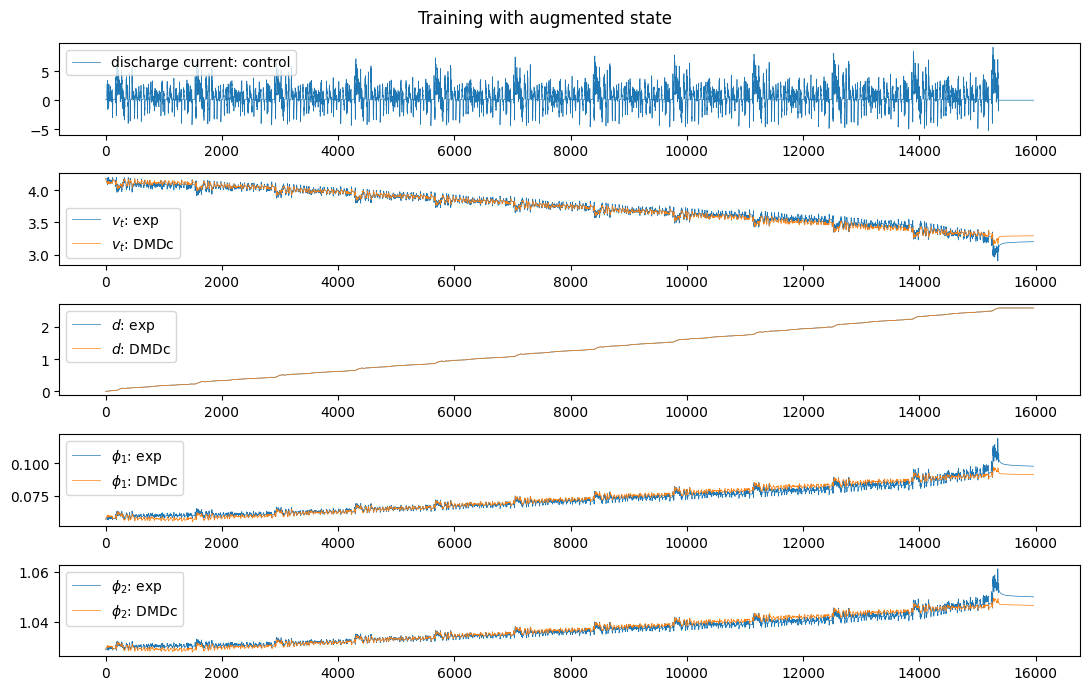

In [5]:
initial_state = state_data[0, :]
n_steps = state_data.shape[0] - 1
lw = 0.5
pred_state = model.simulate(initial_state, u=control_data[:-1], n_steps=n_steps)
pred_state = np.vstack([initial_state, pred_state])

print("RMS: error:", compute_prediction_error(pred_state, state_data))

fig, axs = plt.subplots(len(state_names) + 1, 1, figsize=(11, 7))
axs[0].plot(t_train, control_data[:, 0], label="discharge current: control", lw=lw)
axs[0].legend()
for i, ax in enumerate(axs[1:]):
    ax.plot(t_train, state_data[:, i], label=state_names[i] + ": exp", lw=lw)
    ax.plot(t_train, pred_state[:, i], label=state_names[i] + ": DMDc", lw=lw)
    ax.legend(loc="best")
fig.suptitle("Training with augmented state")
plt.tight_layout()
plt.show()

The learnt data-driven model is not perfect, but indeed much better than the previous version. We can test the models performance on unseen data for validation

RMS: error: [0.051339908937880804, 0.0043276617449865065, 0.0032885498748125687, 0.0017280453857355118]


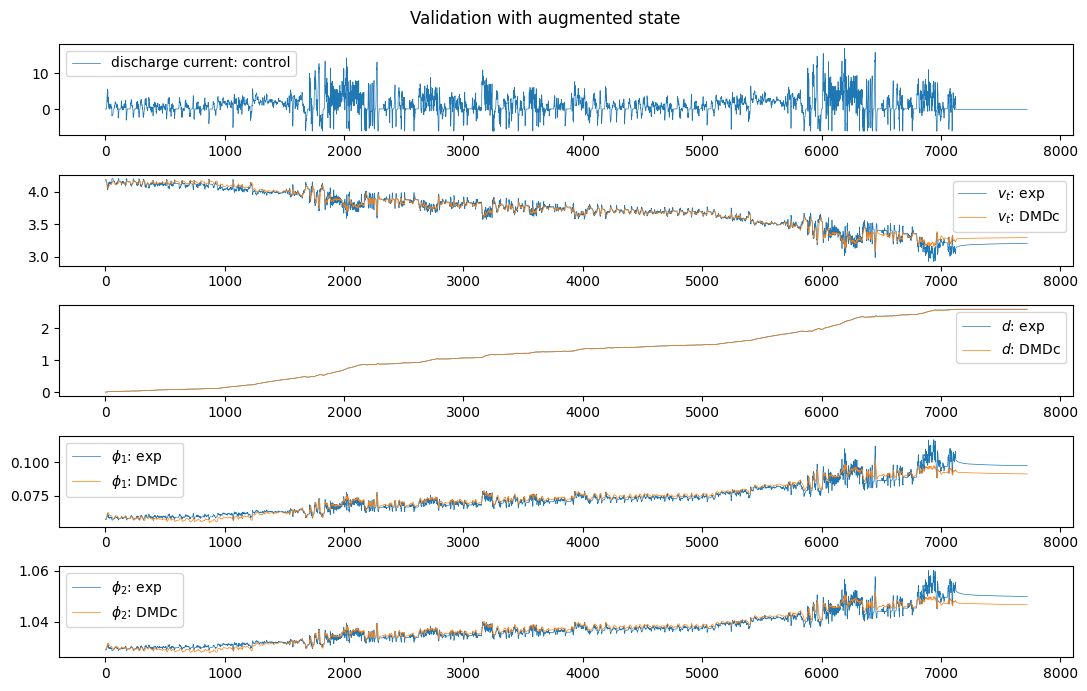

In [6]:
state_data = np.vstack([vt_val, d_val, f_phi1(vt_val), f_phi2(vt_val)]).T
control_data = curr_val.reshape((curr_val.size, 1))

initial_state = state_data[0, :]
n_steps = state_data.shape[0] - 1
lw = 0.5
pred_state = model.simulate(initial_state, u=control_data[:-1], n_steps=n_steps)
pred_state = np.vstack([initial_state, pred_state])

print("RMS: error:", compute_prediction_error(pred_state, state_data))

fig, axs = plt.subplots(len(state_names) + 1, 1, figsize=(11, 7))
axs[0].plot(t_val, control_data[:, 0], label="discharge current: control", lw=lw)
axs[0].legend()
for i, ax in enumerate(axs[1:]):
    ax.plot(t_val, state_data[:, i], label=state_names[i] + ": exp", lw=lw)
    ax.plot(t_val, pred_state[:, i], label=state_names[i] + ": DMDc", lw=lw)
    ax.legend(loc="best")
fig.suptitle("Validation with augmented state")
plt.tight_layout()
plt.show()

One may try to improve the data-driven model further by using additional features, or consider alternative algorithms such as the extended DMDc and/or PySindy. These alternatively algorightms are showcased in subsequent tutorials.

## Including the DMDc model in Collimator

Similarly to the previous tutorials in this series, ultimately our goal is to be able to include the battery model in Collimator, so that it can be utilised in a wider system model.

To achieve this, we can write two additional LeafSystems as shown below. The `DiscreteLinearSystem` effectively simulates the discrete dynamics $\mathbf{x}[k+1] = A \mathbf{x}[k] + B \mathbf{u}$, and the `DiscreteSource` system provides the discrete control input sequence. For the latter, one may also utilise the pre-built `DataSource` in Collimator (see Collimator documentation and source: `/library/data_source.py`).

In [8]:
import collimator
from collimator.framework import LeafSystem
from collimator.library import Constant

from collimator.simulation import SimulatorOptions, ODESolverOptions

from typing import NamedTuple


class DiscreteLinearSystem(LeafSystem):
    """
    x[k+1] = A x[k] + B u[k]
    """

    def __init__(self, A, B, dt, initial_state=None, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.A = A
        self.B = B
        self.nx, self.nu = B.shape
        self.dt = dt

        self.declare_input_port()

        if initial_state is None:
            initial_state = jnp.zeros(nx)

        self.declare_discrete_state(default_value=initial_state)

        self.declare_periodic_update(
            self._update_state,
            period=self.dt,
            offset=0.0,
        )

        self.declare_output_port(
            self._compute_output,
            default_value=initial_state,
            period=self.dt,
            offset=0.0,
            requires_inputs=False
        )

    def _compute_output(self, time, state, **params):
        return state.discrete_state

    def _update_state(self, time, state, u, **params):
        x = state.discrete_state
        # Dynamics: y = Ax + Bu
        y = jnp.matmul(self.A, x) + jnp.matmul(self.B, jnp.atleast_1d(u))
        return y


class DiscreteSource(LeafSystem):
    class DiscreteStateType(NamedTuple):
        index: jnp.int64
        source_val: jnp.float64

    def __init__(self, val_array, dt, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.val_array = val_array
        self.dt = dt

        self.declare_discrete_state(
            default_value=self.DiscreteStateType(index=0, source_val=val_array[0]),
            as_array=False,
        )

        self.declare_periodic_update(
            self._update,
            period=self.dt,
            offset=0,
        )

        self.declare_output_port(
            self._compute_output,
            default_value=self.val_array[0],
            period=self.dt,
            offset=0.0,
            requires_inputs = False,
        )

    def _compute_output(self, time, state, **params):
        return state.discrete_state.source_val

    def _update(self, time, state, *inputs, **params):
        index = state.discrete_state.index
        index = index + 1
        source_val = self.val_array[index]
        return self.DiscreteStateType(index=index, source_val=source_val)

We can now include the learnt data-driven system in Collimator and simulate.

In [9]:
builder = collimator.DiagramBuilder()
initial_state = jnp.array(
    [vt_train[0], d_train[0], f_phi1(vt_train[0]), f_phi2(vt_train[0])]
)
dt = 0.1

dls = builder.add(
    DiscreteLinearSystem(
        jnp.array(Aest), jnp.array(Best), dt=dt, initial_state=initial_state, name="dls"
    )
)
control = builder.add(DiscreteSource(jnp.array(curr_train), dt=dt, name="control"))

builder.connect(control.output_ports[0], dls.input_ports[0])

diagram = builder.build()
context = diagram.create_context()

recorded_signals = {
    "state": diagram["dls"].output_ports[0],
    "control": diagram["control"].output_ports[0],
}

options = SimulatorOptions(max_major_steps=ceil(t_train[-1] / dt))
sol = collimator.simulate(
    diagram,
    context,
    (0.0, t_train[-1]),
    options=options,
    recorded_signals=recorded_signals,
)

collimator:INFO Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=159656, ode_solver_method=default, rtol=0.001, atol=1e-06, min_minor_step_size=None, max_minor_step_size=None, max_minor_steps_per_major_step=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True), DiffraxSolver(system=Diagram(root, 2 nodes), rtol=0.001, atol=1e-06, max_steps=4096, max_step_size=None, min_step_size=None, method='default', save_steps=True, return_step_interpolant=False)
[simulator.py:394 -             simulate() ] Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=159656, ode_solver_method=default, rtol=0.001, atol=1e-06, min_minor_step_size=None, max_minor_step_size=None, max_minor_steps_per_major_step=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True), DiffraxSolver(

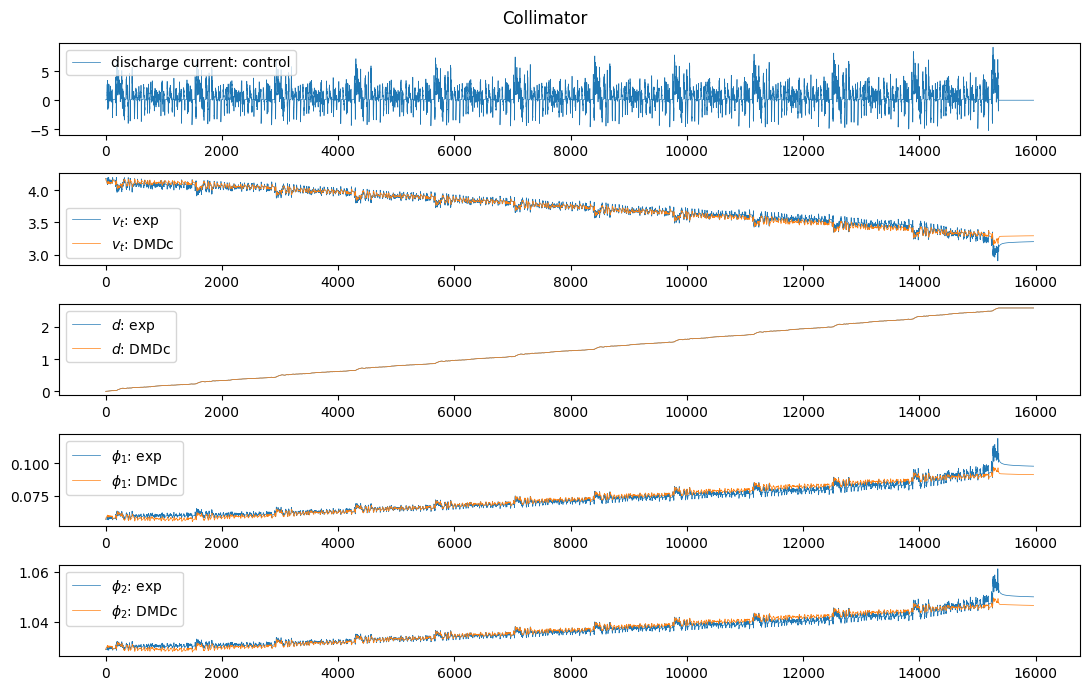

In [10]:
state_data = np.vstack(
    [vt_train, d_train, f_phi1(vt_train), f_phi2(vt_train)]
).T  # exp data for plotting

fig, axs = plt.subplots(len(state_names) + 1, 1, figsize=(11, 7))
axs[0].plot(sol.time, sol.outputs["control"], label="discharge current: control", lw=lw)
axs[0].legend()
for i, ax in enumerate(axs[1:]):
    ax.plot(t_train, state_data[:, i], label=state_names[i] + ": exp", lw=lw)
    ax.plot(
        sol.time, sol.outputs["state"][:, i], label=state_names[i] + ": DMDc", lw=lw
    )
    ax.legend(loc="best")
fig.suptitle("Collimator")
plt.tight_layout()
plt.show()